CELL 1 — Imports


In [48]:
import numpy as np
import pandas as pd

from pyfaidx import Fasta

from scipy.optimize import nnls

from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

%matplotlib inline

CELL 2 — Load COSMIC SBS Matrix


In [49]:
cosmic = pd.read_csv("data/COSMIC_v3.6_SBS_GRCh38.txt", sep="\t")

print(cosmic.shape)
cosmic.head()

(96, 102)


,Type,SBS1,SBS2,SBS3,SBS4,SBS5,SBS6,SBS7a,SBS7b,SBS7c,...,SBS104,SBS105,SBS106,SBS107,SBS108,SBS109,SBS110,SBS111,SBS112,SBS113
0,A[C>A]A,0.000876,5.789892e-07,0.020920,0.042451,0.012052,0.000425,0.000067,0.002344,0.004841,...,0.010658,0.002101,0.000376,0.005540,0.005254,0.018792,0.008594,0.011217,0.007012,0.095867
1,A[C>A]C,0.002220,1.455043e-04,0.016343,0.032990,0.009337,0.000516,0.000177,0.000457,0.001135,...,0.009649,0.003659,0.000329,0.025288,0.001513,0.012304,0.012468,0.012825,0.026770,0.003305
2,A[C>A]G,0.000180,5.361706e-05,0.001808,0.016116,0.001908,0.000053,0.000073,0.000192,0.000388,...,0.001615,0.000262,0.000030,0.001584,0.000418,0.001554,0.000911,0.001145,0.002094,0.000246
3,A[C>A]T,0.001265,9.758841e-05,0.012265,0.029663,0.006636,0.000180,0.000249,0.000714,0.001964,...,0.011605,0.004275,0.000449,0.051158,0.002855,0.014507,0.006085,0.009626,0.009638,0.003447
4,A[C>G]A,0.001839,2.226114e-16,0.019813,0.006931,0.010144,0.000471,0.000065,0.000009,0.001123,...,0.004958,0.000446,0.000779,0.000186,0.000972,0.008482,0.004342,0.004327,0.002774,0.005204


CELL 3 — Separate Contexts and Signatures


In [50]:
contexts = cosmic["Type"]

signature_matrix = cosmic.drop(columns=["Type"])

print(signature_matrix.shape)

(96, 101)


CELL 4 — Check Signatures


In [51]:
print(signature_matrix.columns.tolist()[:20])

['SBS1', 'SBS2', 'SBS3', 'SBS4', 'SBS5', 'SBS6', 'SBS7a', 'SBS7b', 'SBS7c', 'SBS7d', 'SBS8', 'SBS9', 'SBS10a', 'SBS10b', 'SBS10c', 'SBS10d', 'SBS11', 'SBS12', 'SBS13', 'SBS14']


CELL 5 — Load Filtered Somatic VCF


In [52]:
mutations = []

with open("data/SomaticBrca_P1.vcf") as f:

    for line in f:

        if line.startswith("#"):
            continue

        cols = line.strip().split("\t")

        chrom = cols[0]
        pos = int(cols[1])
        ref = cols[3]
        alt = cols[4]

        if len(ref) == 1 and len(alt) == 1:

            mutations.append((chrom, pos, ref, alt))

print("Total SNVs:", len(mutations))

Total SNVs: 722


CELL 6 — Load Reference Genome


In [53]:
genome = Fasta("data/GRCh38.fa")

CELL 7 — Complement Dictionary


In [54]:
comp = {"A": "T", "T": "A", "C": "G", "G": "C"}

CELL 8 — SBS96 Normalization Function


In [55]:
def normalize_context(left, ref, alt, right):

    if ref in ["C", "T"]:

        return f"{left}[{ref}>{alt}]{right}"

    new_left = comp[right]
    new_right = comp[left]

    new_ref = comp[ref]
    new_alt = comp[alt]

    return f"{new_left}[{new_ref}>{new_alt}]{new_right}"

CELL 9 — Extract SBS96 Contexts


In [56]:
contexts_found = []

for chrom, pos, ref, alt in mutations:

    left = genome[chrom][pos - 2].seq
    right = genome[chrom][pos].seq

    sbs = normalize_context(left, ref, alt, right)

    contexts_found.append(sbs)

print(contexts_found[:10])

['T[C>T]T', 'A[C>T]C', 'T[C>T]G', 'T[C>G]A', 'T[C>T]A', 'T[C>G]C', 'T[C>T]A', 'T[C>G]A', 'T[C>G]T', 'T[C>T]A']


CELL 10 — Initialize SBS96 Vector


In [57]:
SBS96 = {x: 0 for x in contexts}

print(len(SBS96))

96


CELL 11 — Count Mutations


In [58]:
for context in contexts_found:

    if context in SBS96:

        SBS96[context] += 1

CELL 12 — Convert to Vector


In [59]:
tumor_vector = np.array([SBS96[x] for x in contexts])

print(tumor_vector.shape)

print(tumor_vector.sum())

(96,)
722


CELL 13 — Normalize Tumor Profile


In [60]:
tumor_profile = tumor_vector / tumor_vector.sum()

print(tumor_profile.sum())

1.0


CELL 14 — Plot SBS96 Spectrum


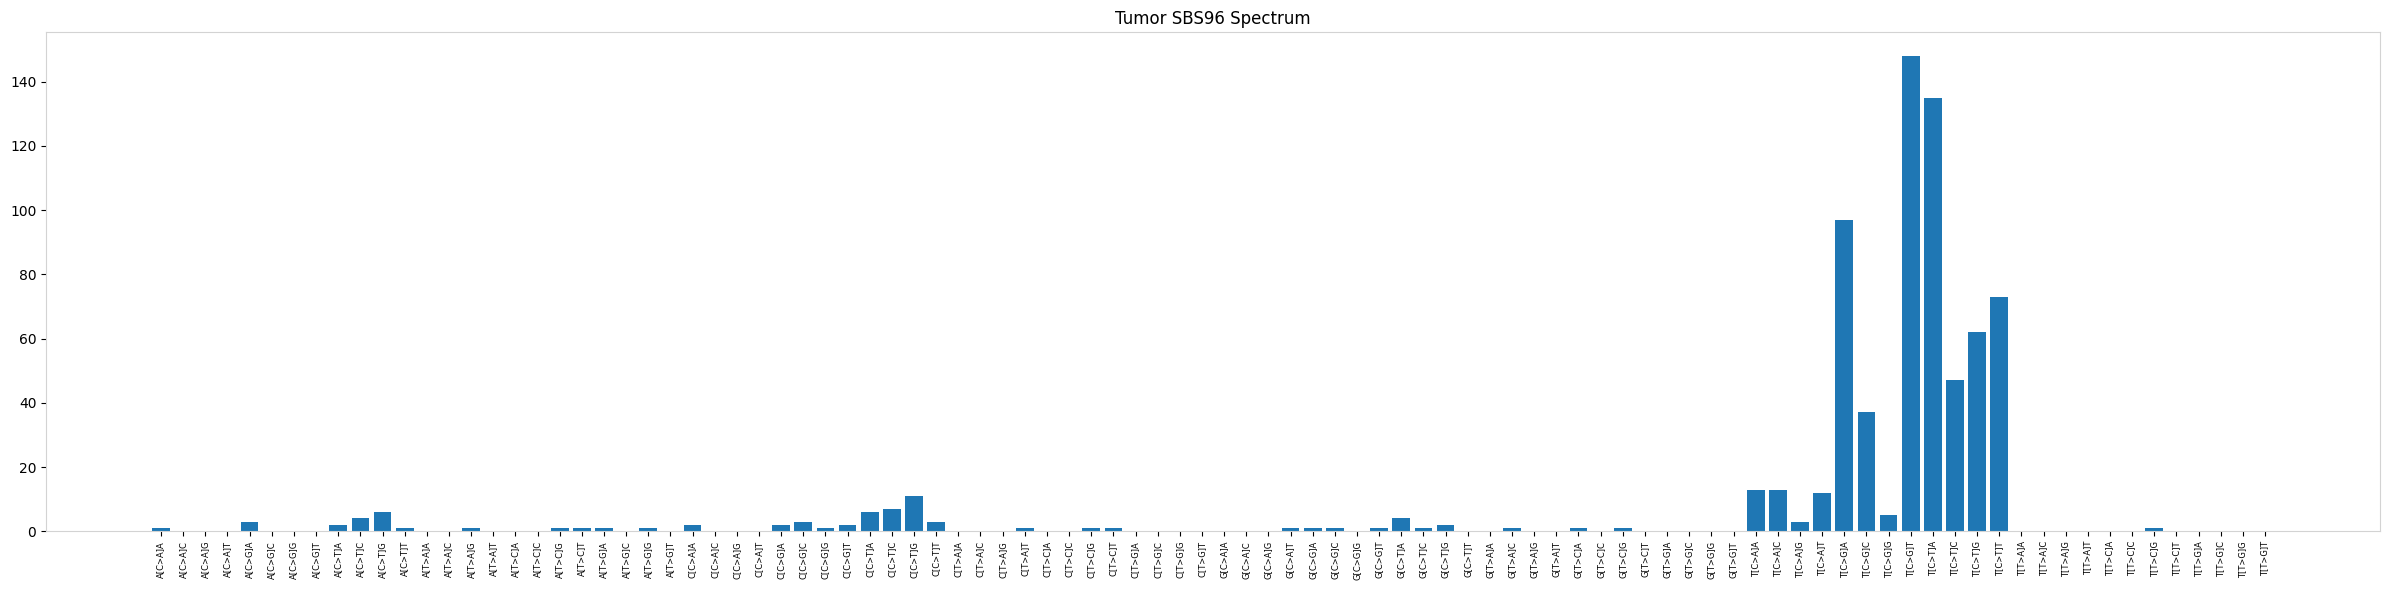

In [61]:
plt.figure(figsize=(24, 6))

plt.bar(list(SBS96.keys()), list(SBS96.values()))

plt.xticks(rotation=90, fontsize=6)

plt.title("Tumor SBS96 Spectrum")

plt.tight_layout()

plt.show()

CELL 15 — Calculate Cosine Similarity Against Every COSMIC Signature


In [62]:
cosine_scores = []

for sig in signature_matrix.columns:

    score = cosine_similarity(
        tumor_profile.reshape(1, -1), signature_matrix[sig].values.reshape(1, -1)
    )[0][0]

    cosine_scores.append((sig, score))

cosine_scores = sorted(cosine_scores, key=lambda x: x[1], reverse=True)

pd.DataFrame(cosine_scores, columns=["Signature", "Cosine"]).head(20)

,Signature,Cosine
0,SBS13,0.725716
1,SBS2,0.650146
2,SBS103,0.589559
3,SBS7a,0.555716
4,SBS40a,0.469285
5,SBS86,0.465535
6,SBS110,0.434696
7,SBS39,0.418221
8,SBS30,0.376532
9,SBS102,0.374728


CELL 16 — Initial NNLS Fit


In [63]:
COSMIC = signature_matrix.values

weights, residual = nnls(COSMIC, tumor_profile)

print("Residual:", residual)

Residual: 0.04881121402222374


CELL 17 — View Initial Fit


In [64]:
initial_fit = pd.DataFrame({"Signature": signature_matrix.columns, "Weight": weights})

initial_fit = initial_fit.sort_values(by="Weight", ascending=False)

initial_fit.head(20)

,Signature,Weight
18,SBS13,0.478120
1,SBS2,0.286967
13,SBS10b,0.117102
6,SBS7a,0.095162
73,SBS86,0.041596
74,SBS87,0.037249
90,SBS103,0.020894
0,SBS1,0.012256
64,SBS54,0.001066
84,SBS97,0.001004


CELL 18 — Candidate Signature Selection


In [65]:
candidate_signatures = initial_fit[initial_fit["Weight"] > 0.02]

candidate_signatures

,Signature,Weight
18,SBS13,0.478120
1,SBS2,0.286967
13,SBS10b,0.117102
6,SBS7a,0.095162
73,SBS86,0.041596
74,SBS87,0.037249
90,SBS103,0.020894


CELL 19 — Build Reduced COSMIC Matrix


In [66]:
selected = candidate_signatures["Signature"].tolist()

COSMIC_reduced = signature_matrix[selected].values

print(COSMIC_reduced.shape)

(96, 7)


CELL 20 — Refit


In [67]:
weights_refit, residual_refit = nnls(COSMIC_reduced, tumor_profile)

print(residual_refit)

0.048969889013976156


CELL 21 — Final Results


In [68]:
final_result = pd.DataFrame({"Signature": selected, "Weight": weights_refit})

final_result = final_result.sort_values(by="Weight", ascending=False)

final_result

,Signature,Weight
0,SBS13,0.477725
1,SBS2,0.286964
2,SBS10b,0.117685
3,SBS7a,0.094944
5,SBS87,0.054622
4,SBS86,0.042116
6,SBS103,0.020543


CELL 22 — Normalize Contributions


In [69]:
final_result["Contribution"] = final_result["Weight"] / final_result["Weight"].sum()

final_result["Contribution_%"] = (final_result["Contribution"] * 100).round(1)

final_result

,Signature,Weight,Contribution,Contribution_%
0,SBS13,0.477725,0.436438,43.6
1,SBS2,0.286964,0.262164,26.2
2,SBS10b,0.117685,0.107514,10.8
3,SBS7a,0.094944,0.086738,8.7
5,SBS87,0.054622,0.049901,5.0
4,SBS86,0.042116,0.038477,3.8
6,SBS103,0.020543,0.018768,1.9


CELL 23 — Reconstruct Tumor Profile


In [70]:
reconstructed = COSMIC_reduced @ weights_refit

CELL 24 — Reconstruction Cosine Similarity


In [71]:
reconstruction_cosine = cosine_similarity(
    tumor_profile.reshape(1, -1), reconstructed.reshape(1, -1)
)[0][0]

print("Cosine:", reconstruction_cosine)

Cosine: 0.9900523087537683


CELL 25 — RMSE


In [72]:
rmse = np.sqrt(np.mean((tumor_profile - reconstructed) ** 2))

print("RMSE:", rmse)

RMSE: 0.0049979683685402185


CELL 26 — Residual Plot


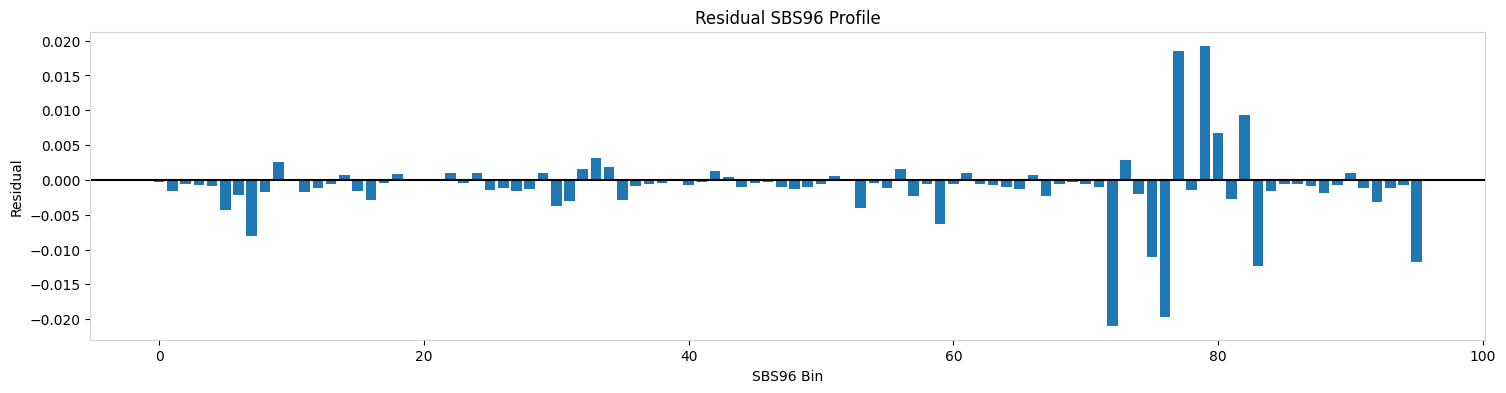

In [73]:
residuals = tumor_profile - reconstructed

plt.figure(figsize=(18, 4))

plt.bar(range(96), residuals)

plt.axhline(0, color="black")

plt.title("Residual SBS96 Profile")

plt.xlabel("SBS96 Bin")

plt.ylabel("Residual")

plt.show()

CELL 27 — Biological Annotation


In [74]:
signature_info = {
    "SBS1": "Age-related",
    "SBS2": "APOBEC activity",
    "SBS3": "Homologous recombination deficiency",
    "SBS4": "Smoking",
    "SBS5": "Clock-like",
    "SBS7a": "UV exposure",
    "SBS7b": "UV exposure",
    "SBS10a": "POLE defect",
    "SBS10b": "POLE defect",
    "SBS13": "APOBEC activity",
    "SBS15": "MMR deficiency",
    "SBS18": "ROS damage",
    "SBS36": "BER deficiency",
    "SBS44": "MMR deficiency",
    "SBS86": "MMR deficiency",
}

CELL 28 — Final Report


In [75]:
report = final_result.copy()

report["Meaning"] = report["Signature"].map(signature_info)

report

,Signature,Weight,Contribution,Contribution_%,Meaning
0,SBS13,0.477725,0.436438,43.6,APOBEC activity
1,SBS2,0.286964,0.262164,26.2,APOBEC activity
2,SBS10b,0.117685,0.107514,10.8,POLE defect
3,SBS7a,0.094944,0.086738,8.7,UV exposure
5,SBS87,0.054622,0.049901,5.0,NaN
4,SBS86,0.042116,0.038477,3.8,MMR deficiency
6,SBS103,0.020543,0.018768,1.9,NaN


CELL 29 — Export CSV


In [76]:
report.to_csv("SBS_signature_report.csv", index=False)

CELL 30 — Clinical Interpretation


In [77]:
for _, row in report.iterrows():

    print(
        f"{row['Signature']} "
        f"({row['Contribution_%']}%) "
        f"--> "
        f"{row['Meaning']}"
    )

SBS13 (43.6%) --> APOBEC activity
SBS2 (26.2%) --> APOBEC activity
SBS10b (10.8%) --> POLE defect
SBS7a (8.7%) --> UV exposure
SBS87 (5.0%) --> nan
SBS86 (3.8%) --> MMR deficiency
SBS103 (1.9%) --> nan


CELL 31 — Save SBS96 Matrix for Validation


In [78]:
!pip install SigProfilerAssignment

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


CELL 32 — Create SBS96 Matrix File


In [79]:
import pandas as pd

sigprofiler_input = pd.DataFrame({"MutationType": contexts, "Tumor_1": tumor_vector})

sigprofiler_input.head()

,MutationType,Tumor_1
0,A[C>A]A,1
1,A[C>A]C,0
2,A[C>A]G,0
3,A[C>A]T,0
4,A[C>G]A,3


CELL 33 — Save Matrix


In [80]:
sigprofiler_input.to_csv("Tumor_SBS96.txt", sep="\t", index=False)

CELL 35 — Run SigProfilerAssignment


In [81]:
from SigProfilerAssignment import Analyzer

Analyzer.cosmic_fit(
    samples="Tumor_SBS96.txt",
    output="SigProfiler_Output",
    input_type="matrix",
    context_type="96",
    collapse_to_SBS96=False,
    genome_build="GRCh38",
    cosmic_version=3.4,
    make_plots=True,
)

Assigning COSMIC sigs or Signature Database ...... 


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished




 
Your Job Is Successfully Completed! Thank You For Using SigProfilerAssignment.
 


CELL 36 — Load SigProfiler Results


In [82]:
sigprofiler_result = pd.read_csv(
    "SigProfiler_Output/Assignment_Solution/Activities/"
    "Assignment_Solution_Activities.txt",
    sep="\t",
)

sigprofiler_result

,Samples,SBS1,SBS2,SBS3,SBS4,SBS5,SBS6,SBS7a,SBS7b,SBS7c,...,SBS90,SBS91,SBS92,SBS93,SBS94,SBS95,SBS96,SBS97,SBS98,SBS99
0,Tumor_1,20,235,0,0,24,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


CELL 37 — Reformat SigProfiler Output


In [83]:
sp = sigprofiler_result.T

sp.columns = ["Contribution"]

sp = sp.iloc[1:]

sp["Contribution"] = sp["Contribution"] / sp["Contribution"].sum()

sp

,Contribution
SBS1,0.027701
SBS2,0.325485
SBS3,0.0
SBS4,0.0
SBS5,0.033241
...,...
SBS95,0.0
SBS96,0.0
SBS97,0.0
SBS98,0.0


CELL 38 — Compare Custom vs SigProfiler


In [84]:
custom = report[["Signature", "Contribution"]].copy()

custom.columns = ["Signature", "Custom"]

comparison = custom.merge(
    sp.reset_index().rename(
        columns={"index": "Signature", "Contribution": "SigProfiler"}
    ),
    on="Signature",
    how="outer",
)

comparison = comparison.fillna(0)

comparison

,Signature,Custom,SigProfiler
0,SBS1,0.000000,0.027701
1,SBS103,0.018768,0.000000
2,SBS10a,0.000000,0.000000
3,SBS10b,0.107514,0.130194
4,SBS10c,0.000000,0.000000
...,...,...,...
82,SBS95,0.000000,0.000000
83,SBS96,0.000000,0.000000
84,SBS97,0.000000,0.000000
85,SBS98,0.000000,0.000000


CELL 39 — Correlation Between Methods


In [85]:
from scipy.stats import pearsonr

r, p = pearsonr(comparison["Custom"], comparison["SigProfiler"])

print("Pearson r =", r)
print("p-value =", p)

Pearson r = 0.9742743092802083
p-value = 8.758368555942788e-57


CELL 40 — Correlation scatter plot


In [86]:
%matplotlib inline

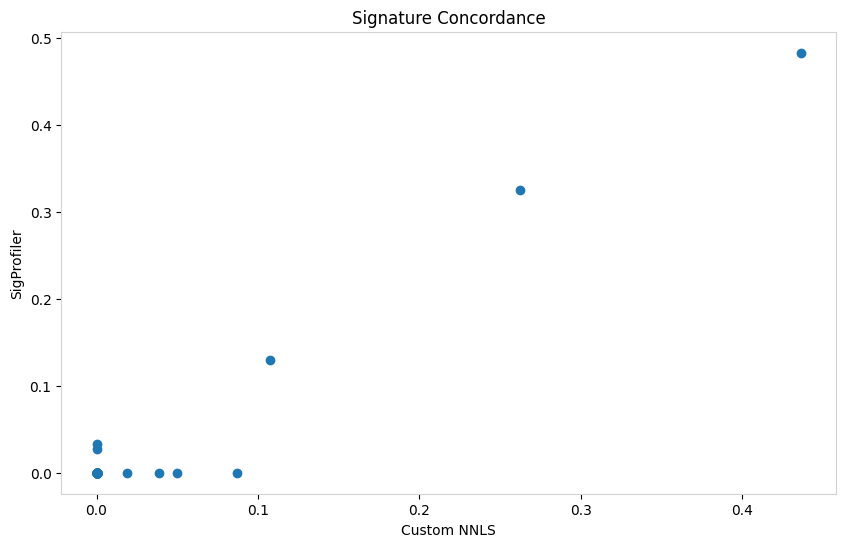

In [87]:
plt.figure(figsize=(10, 6))

plt.scatter(comparison["Custom"], comparison["SigProfiler"])

plt.xlabel("Custom NNLS")
plt.ylabel("SigProfiler")

plt.title("Signature Concordance")

plt.show()

CELL 41 — Difference table


In [88]:
comparison["Difference"] = abs(comparison["Custom"] - comparison["SigProfiler"])

comparison = comparison.sort_values("Difference", ascending=False)

display(comparison.head(20))

,Signature,Custom,SigProfiler,Difference
65,SBS7a,0.086738,0.000000,0.086738
16,SBS2,0.262164,0.325485,0.063321
73,SBS87,0.049901,0.000000,0.049901
8,SBS13,0.436438,0.483380,0.046941
72,SBS86,0.038477,0.000000,0.038477
52,SBS5,0.000000,0.033241,0.033241
0,SBS1,0.000000,0.027701,0.027701
3,SBS10b,0.107514,0.130194,0.022680
1,SBS103,0.018768,0.000000,0.018768
9,SBS14,0.000000,0.000000,0.000000


CELL 42 - Custom vs SigProfiler barplot


In [89]:
%matplotlib inline

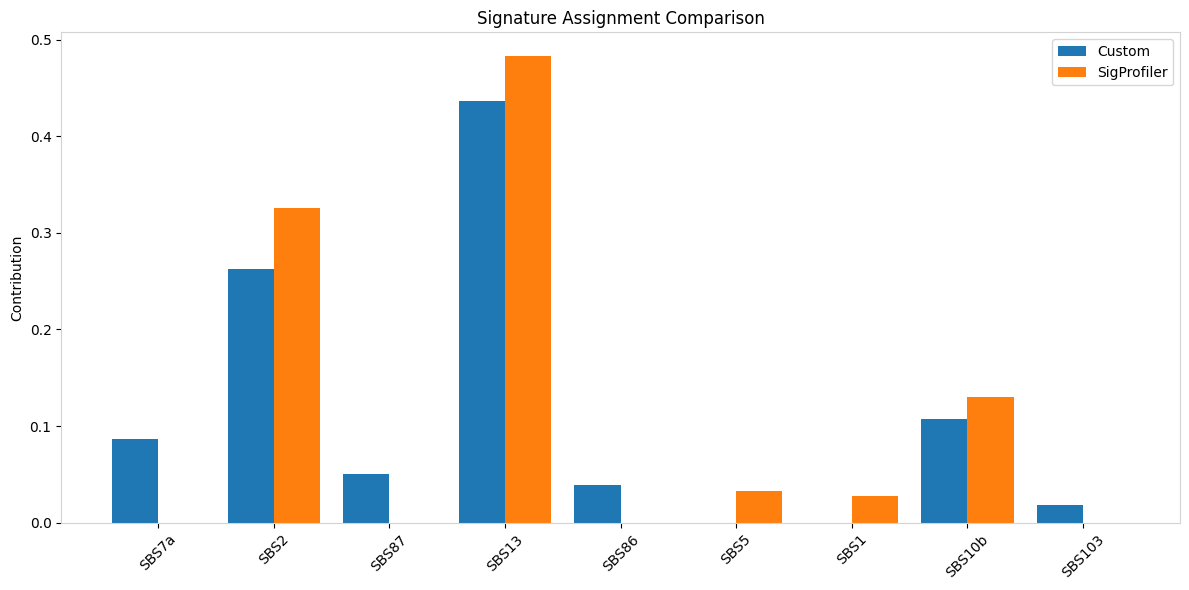

In [90]:
plot_df = comparison.copy()

plot_df = plot_df[(plot_df["Custom"] > 0) | (plot_df["SigProfiler"] > 0)]

plt.figure(figsize=(12, 6))

x = np.arange(len(plot_df))

width = 0.4

plt.bar(x - width / 2, plot_df["Custom"], width, label="Custom")

plt.bar(x + width / 2, plot_df["SigProfiler"], width, label="SigProfiler")

plt.xticks(x, plot_df["Signature"], rotation=45)

plt.ylabel("Contribution")

plt.title("Signature Assignment Comparison")

plt.legend()

plt.tight_layout()

plt.show()

CELL 43 - Observed vs reconstructed SBS96


In [91]:
%matplotlib inline

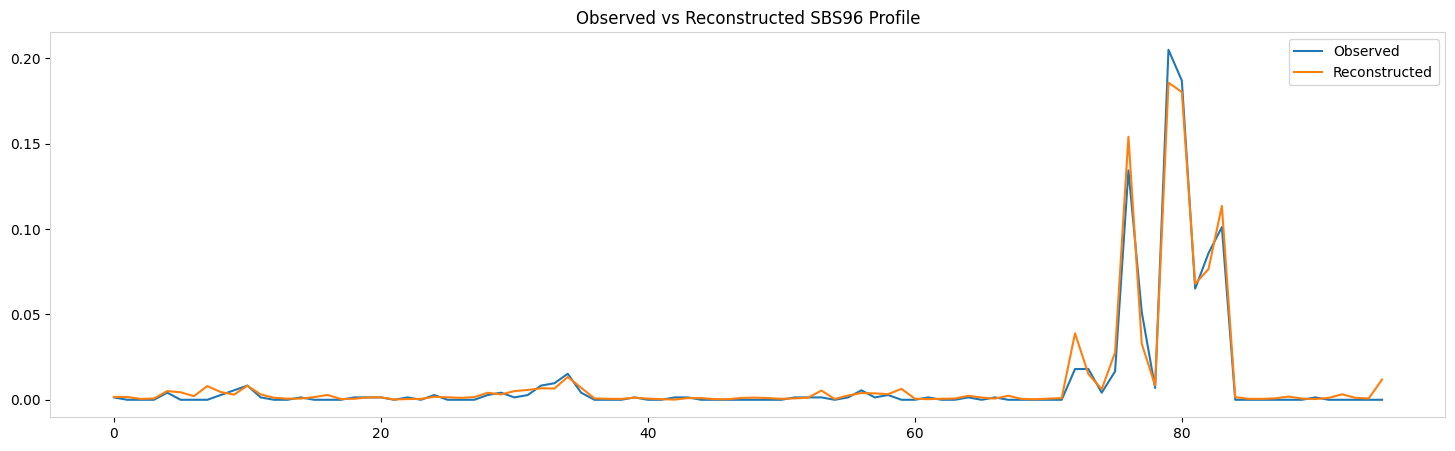

In [92]:
plt.figure(figsize=(18, 5))

plt.plot(tumor_profile, label="Observed")

plt.plot(reconstructed, label="Reconstructed")

plt.legend()

plt.title("Observed vs Reconstructed SBS96 Profile")

plt.show()

CELL 44 - Final signature contributions


In [93]:
%matplotlib inline

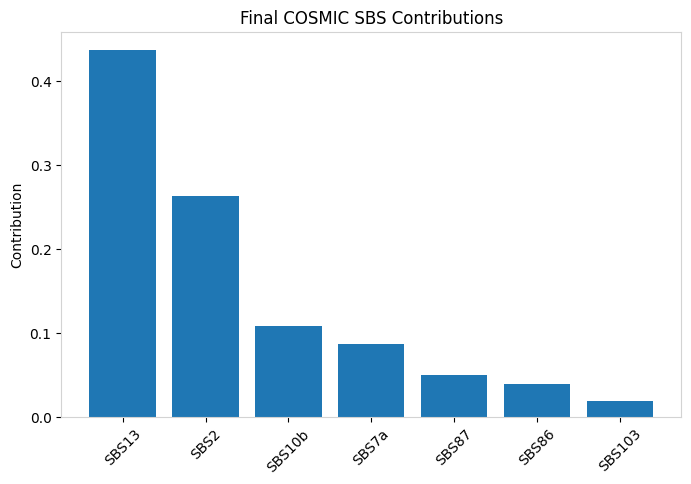

In [94]:
top = final_result.sort_values("Contribution", ascending=False)

plt.figure(figsize=(8, 5))

plt.bar(top["Signature"], top["Contribution"])

plt.ylabel("Contribution")

plt.title("Final COSMIC SBS Contributions")

plt.xticks(rotation=45)

plt.show()

CELL 45 - Validation metrics


In [95]:
%matplotlib inline

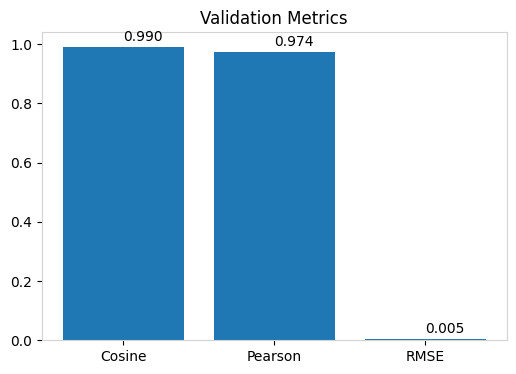

In [99]:
metrics = {"Cosine": reconstruction_cosine, "Pearson": r, "RMSE": rmse}

plt.figure(figsize=(6, 4))

plt.bar(metrics.keys(), metrics.values())

plt.title("Validation Metrics")

for i,v in enumerate(metrics.values()):
    plt.text(i,v+0.02,f"{v:.3f}")

plt.show()

CELL 46 - Final report table


In [97]:
display(report.sort_values("Contribution_%", ascending=False))

,Signature,Weight,Contribution,Contribution_%,Meaning
0,SBS13,0.477725,0.436438,43.6,APOBEC activity
1,SBS2,0.286964,0.262164,26.2,APOBEC activity
2,SBS10b,0.117685,0.107514,10.8,POLE defect
3,SBS7a,0.094944,0.086738,8.7,UV exposure
5,SBS87,0.054622,0.049901,5.0,NaN
4,SBS86,0.042116,0.038477,3.8,MMR deficiency
6,SBS103,0.020543,0.018768,1.9,NaN


In [98]:
import matplotlib

print(matplotlib.get_backend())

inline
